In [3]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
df_train = pd.read_csv("train.csv")
df_test  = pd.read_csv("test.csv")

In [5]:
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [6]:
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  awards_won?           23490 non-null  int64  
 11  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 2.2+ MB


In [9]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,54808.0,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.00,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.00,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.00,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.00,5.0,7.0,37.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.00,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.00,60.0,76.0,99.0
is_promoted,54808.0,0.085170,0.279137,0.0,0.00,0.0,0.0,1.0


In [11]:
print(df_train.shape)
print(df_test.shape)

(54808, 13)
(23490, 12)


In [12]:
len(df_train.columns)

13

## Handling null values

In [13]:
df_train.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [14]:
df_test.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
awards_won?                0
avg_training_score         0
dtype: int64

In [15]:
df_train.isna().sum().sort_values(ascending=False)

previous_year_rating    4124
education               2409
employee_id                0
department                 0
region                     0
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [16]:
df_test.isna().sum().sort_values(ascending=False)

previous_year_rating    1812
education               1034
employee_id                0
department                 0
region                     0
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
length_of_service          0
awards_won?                0
avg_training_score         0
dtype: int64

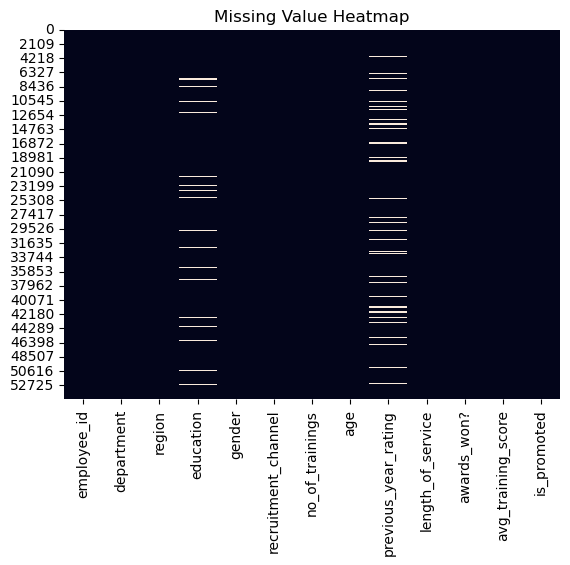

In [17]:
sns.heatmap(df_train.isna(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

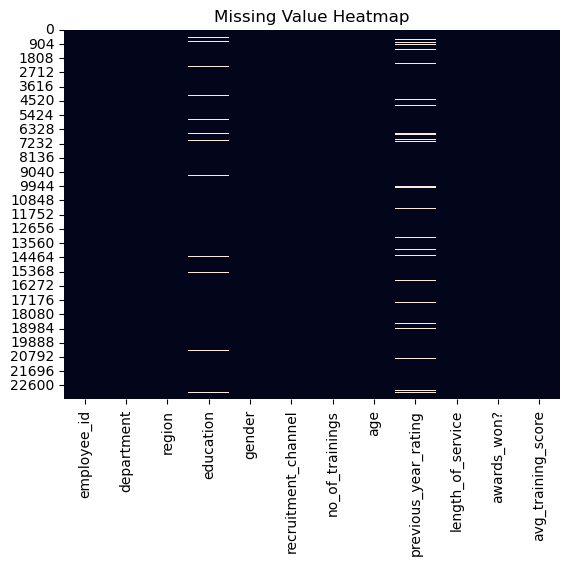

In [18]:
sns.heatmap(df_test.isna(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [19]:
df_train['education'].value_counts()

education
Bachelor's          36669
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64

In [20]:
df_test['education'].value_counts()

education
Bachelor's          15578
Master's & above     6504
Below Secondary       374
Name: count, dtype: int64

In [21]:
df_train['previous_year_rating'].fillna(0,inplace=True)

In [22]:
#removing null values in test set data
df_test['previous_year_rating'].fillna(0,inplace=True)

In [23]:
df_train[df_train['is_promoted']==1].shape

(4668, 13)

In [24]:
df_train[df_train.education.isnull()].is_promoted.sum()

122

In [25]:
#Dropping records with education=NULL
df_train=df_train.dropna()
df_train.shape #2409 records dropped

(52399, 13)

In [26]:
df_train.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

In [27]:
#Dropping records with education=NULL
df_test=df_test.dropna()
df_test.shape #1034 records dropped

(22456, 12)

In [28]:
df_test.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
dtype: int64

In [29]:
#before removing null values
#Training data shape: (54808, 13)
#Testing data shape: (23490, 12)

In [30]:
df_train.duplicated().sum()

0

In [31]:
df_test.duplicated().sum()

0

## Handling Outliers

In [32]:
df_train.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='object')

In [33]:
df_test.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score'],
      dtype='object')

In [34]:
dist_cols = ['no_of_trainings', 'age', 'length_of_service', 'avg_training_score']

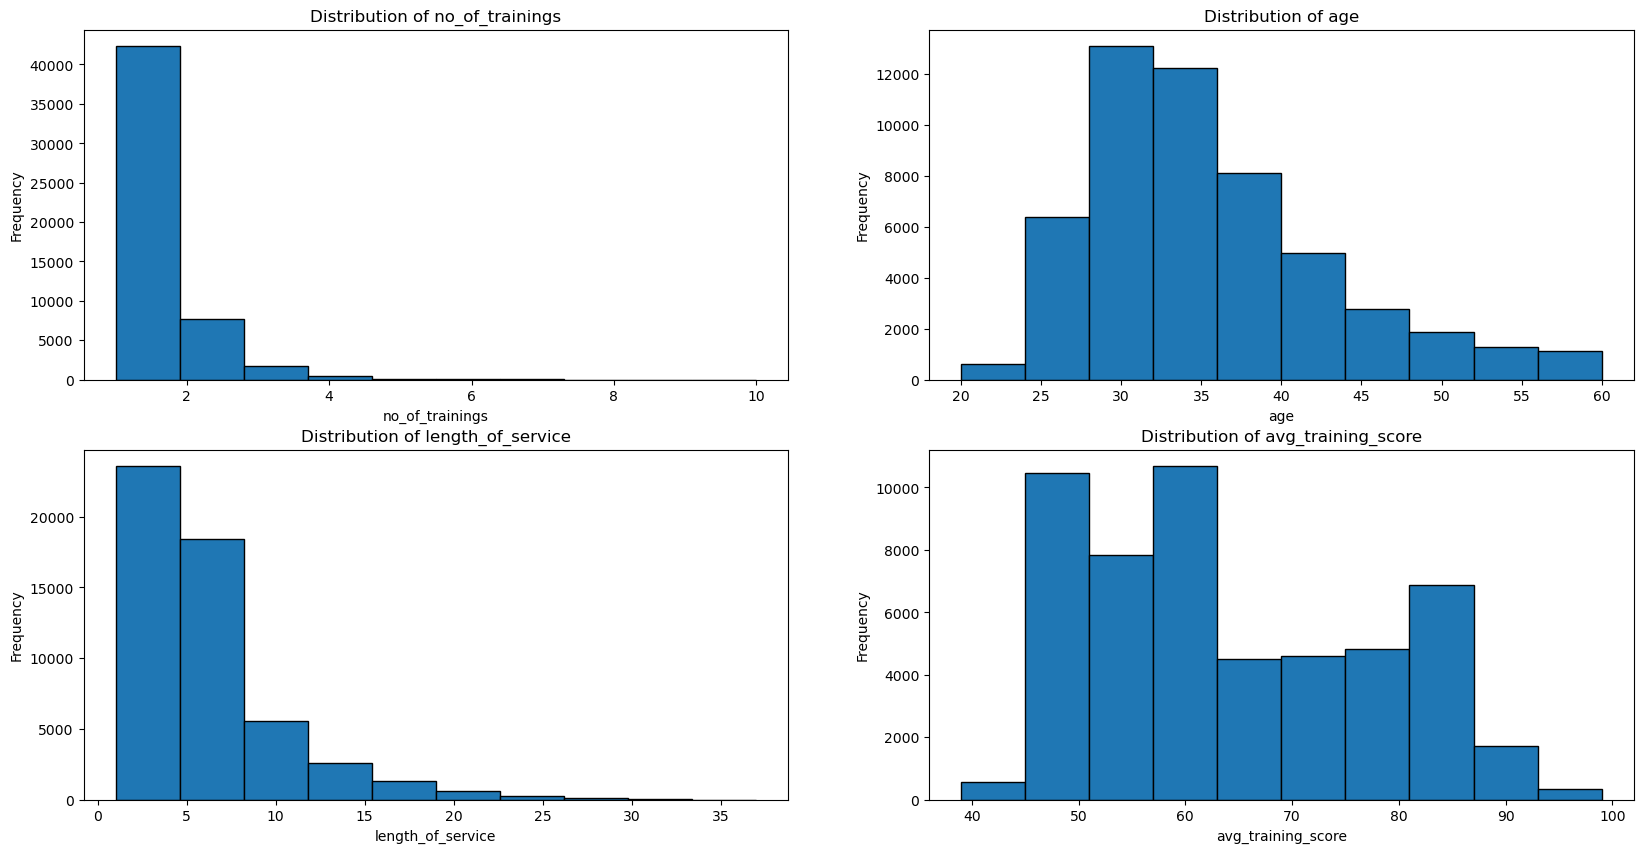

In [35]:
# histogram for outliers in df_train
i = 1
plt.figure(figsize=(20, 10))
for col in dist_cols:
    plt.subplot(2, 2, i)
    plt.hist(df_train[col], bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    i += 1
plt.show()

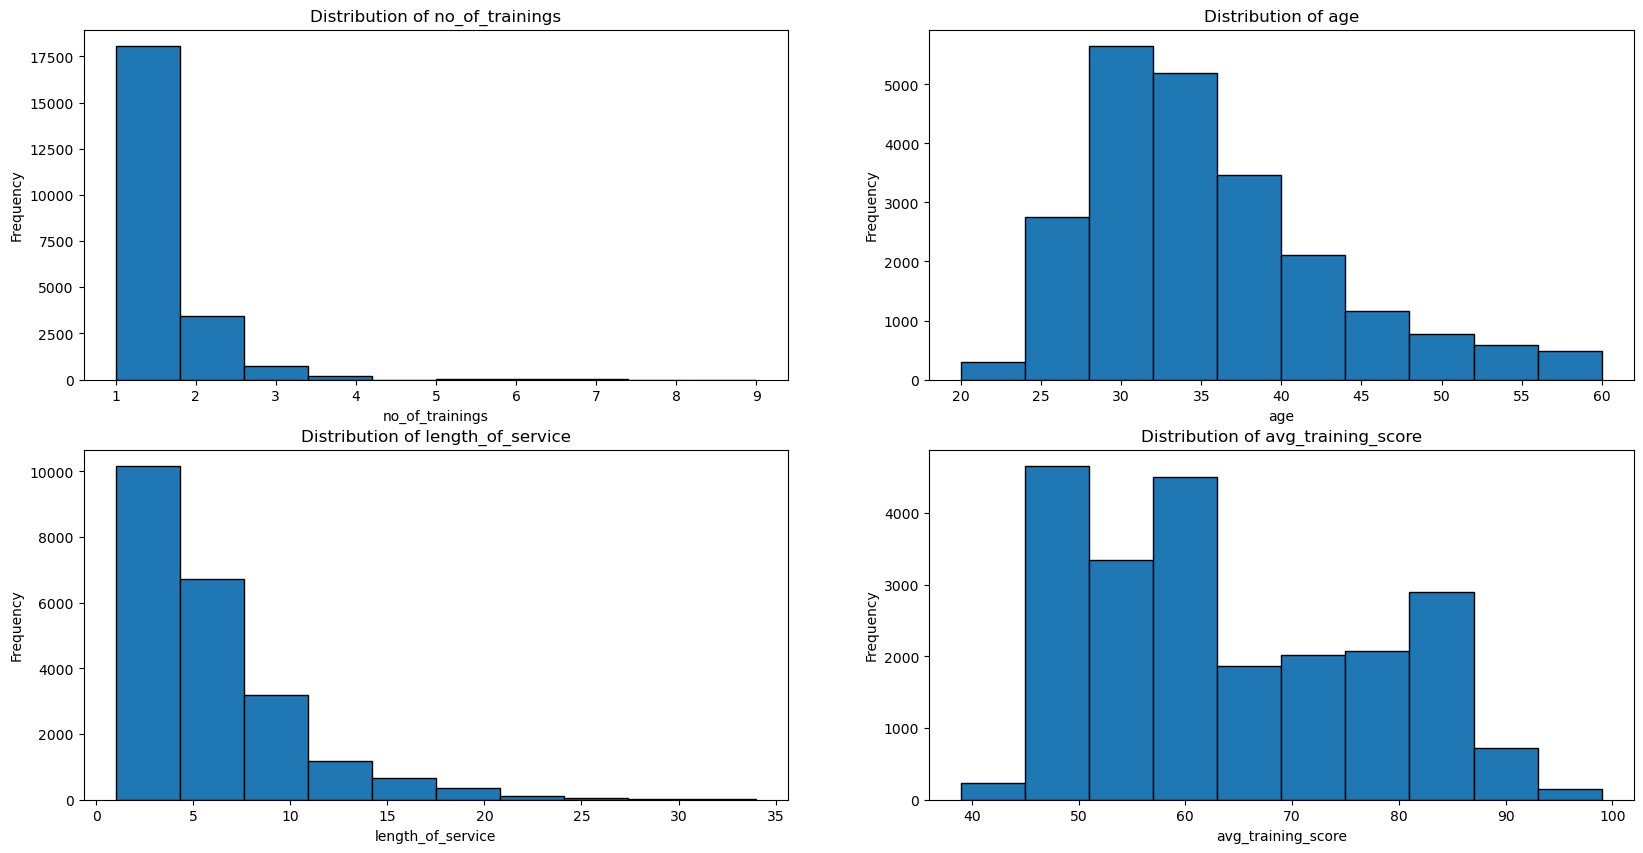

In [37]:
# histogram plot for outliers in df_test
i = 1
plt.figure(figsize=(20, 10))
for col in dist_cols:
    plt.subplot(2, 2, i)
    plt.hist(df_test[col], bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    i += 1
plt.show()

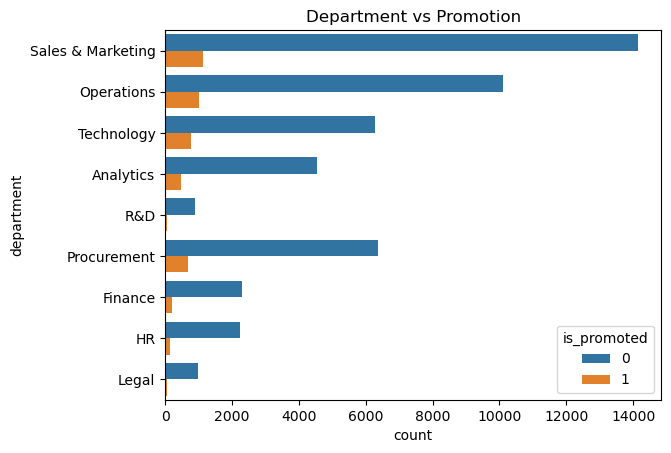

In [36]:
sns.countplot(y="department", hue="is_promoted", data=df_train)
plt.title("Department vs Promotion")
plt.show()

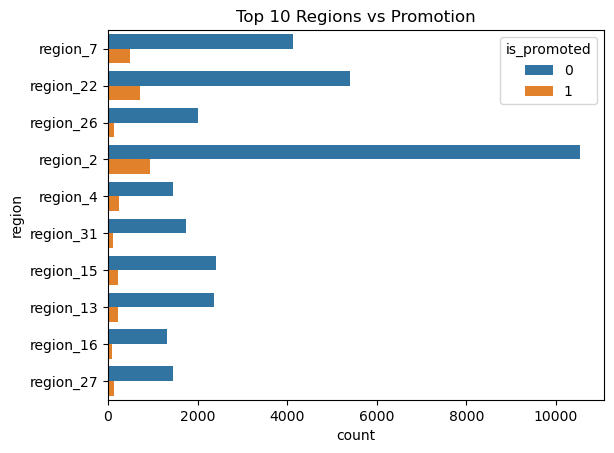

In [37]:
top_regions = df_train["region"].value_counts().head(10).index

sns.countplot(
    y="region",
    hue="is_promoted",
    data=df_train[df_train["region"].isin(top_regions)]
)
plt.title("Top 10 Regions vs Promotion")
plt.show()

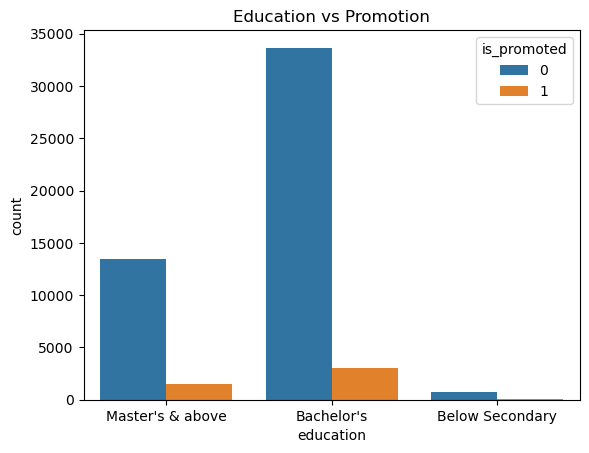

In [38]:
sns.countplot(x="education", hue="is_promoted", data=df_train)
plt.title("Education vs Promotion")
plt.show()

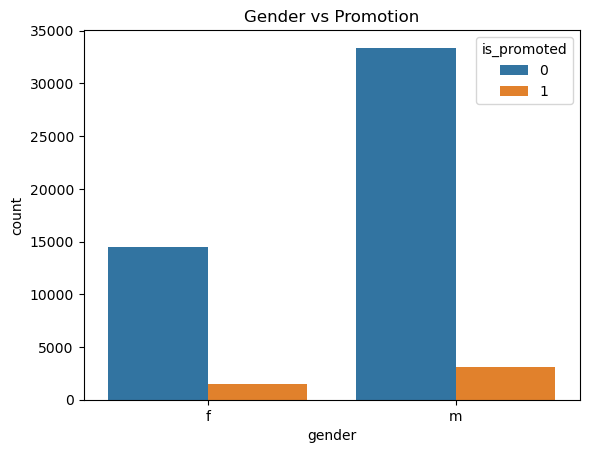

In [39]:
sns.countplot(x="gender", hue="is_promoted", data=df_train)
plt.title("Gender vs Promotion")
plt.show()

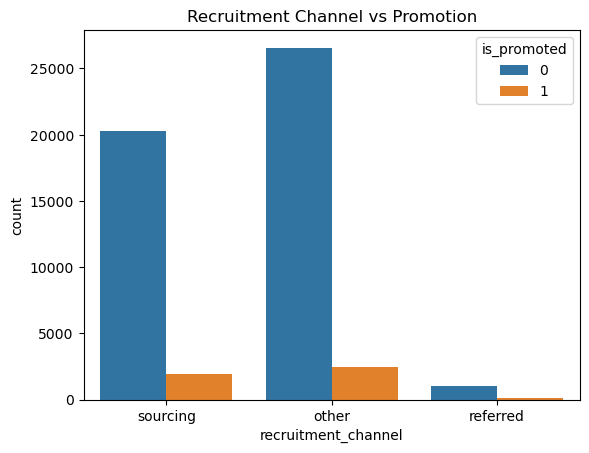

In [40]:
sns.countplot(x="recruitment_channel", hue="is_promoted", data=df_train)
plt.title("Recruitment Channel vs Promotion")
plt.show()

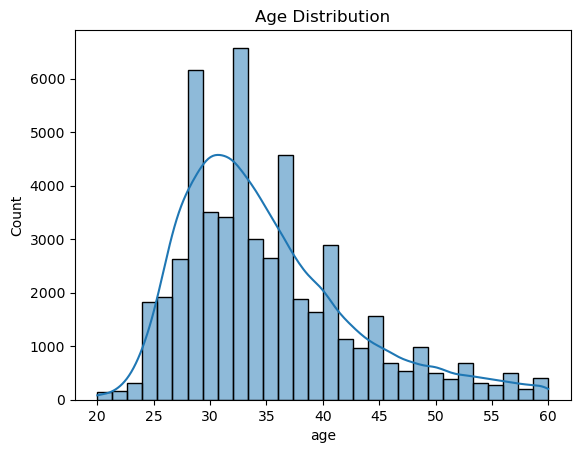

In [41]:
sns.histplot(df_train["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

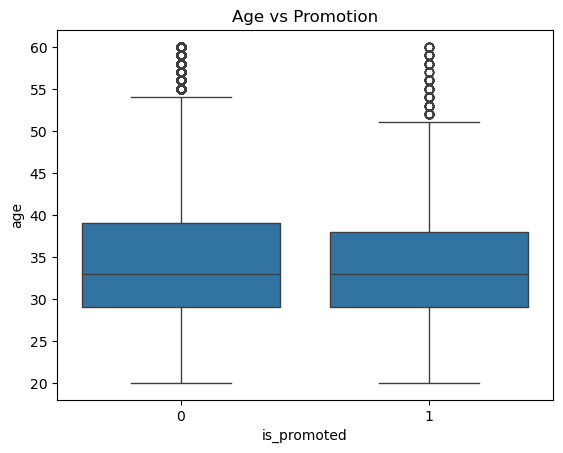

In [42]:
sns.boxplot(x="is_promoted", y="age", data=df_train)
plt.title("Age vs Promotion")
plt.show()

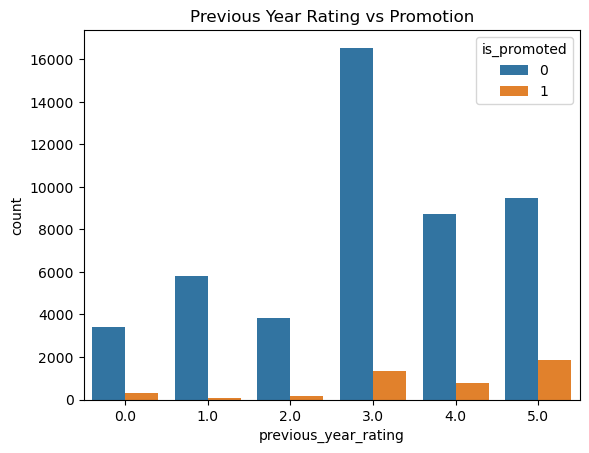

In [43]:
sns.countplot(x="previous_year_rating", hue="is_promoted", data=df_train)
plt.title("Previous Year Rating vs Promotion")
plt.show()

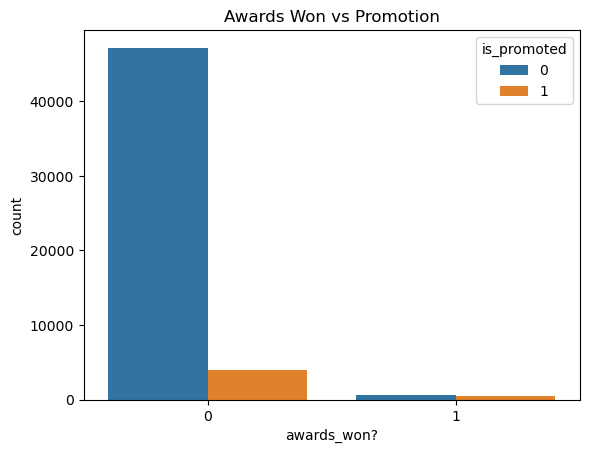

In [44]:
sns.countplot(x="awards_won?", hue="is_promoted", data=df_train)
plt.title("Awards Won vs Promotion")
plt.show()

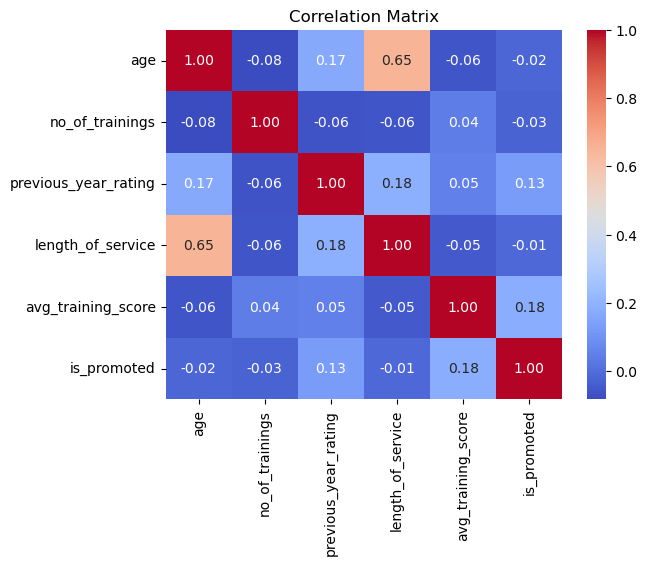

In [45]:
num_cols = [
    "age",
    "no_of_trainings",
    "previous_year_rating",
    "length_of_service",
    "avg_training_score",
    "is_promoted"
]

corr = df_train[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [46]:
# check unique values for all columns in df_train
for col in df_train.columns:
    print(col)
    print(f"Values: \n{df_train[col].unique()}")
    print(f"Number of Values: {len(df_train[col].unique())}")
    print(f"Datatype: {df_train[col].dtype}")
    print("=========================================")

employee_id
Values: 
[65438 65141  7513 ... 74592 13918 51526]
Number of Values: 52399
Datatype: int64
department
Values: 
['Sales & Marketing' 'Operations' 'Technology' 'Analytics' 'R&D'
 'Procurement' 'Finance' 'HR' 'Legal']
Number of Values: 9
Datatype: object
region
Values: 
['region_7' 'region_22' 'region_19' 'region_23' 'region_26' 'region_2'
 'region_20' 'region_34' 'region_1' 'region_4' 'region_29' 'region_31'
 'region_15' 'region_14' 'region_11' 'region_5' 'region_28' 'region_17'
 'region_13' 'region_16' 'region_25' 'region_10' 'region_27' 'region_30'
 'region_12' 'region_21' 'region_8' 'region_32' 'region_6' 'region_33'
 'region_24' 'region_3' 'region_9' 'region_18']
Number of Values: 34
Datatype: object
education
Values: 
["Master's & above" "Bachelor's" 'Below Secondary']
Number of Values: 3
Datatype: object
gender
Values: 
['f' 'm']
Number of Values: 2
Datatype: object
recruitment_channel
Values: 
['sourcing' 'other' 'referred']
Number of Values: 3
Datatype: object
no_of_t

In [47]:
# check unique values for all columns in df_test
for col in df_test.columns:
    print(col)
    print(f"Values: \n{df_test[col].unique()}")
    print(f"Number of Values: {len(df_test[col].unique())}")
    print(f"Datatype: {df_test[col].dtype}")
    print("=========================================")

employee_id
Values: 
[ 8724 74430 72255 ... 45409  1186  5973]
Number of Values: 22456
Datatype: int64
department
Values: 
['Technology' 'HR' 'Sales & Marketing' 'Procurement' 'Finance' 'Analytics'
 'Operations' 'Legal' 'R&D']
Number of Values: 9
Datatype: object
region
Values: 
['region_26' 'region_4' 'region_13' 'region_2' 'region_29' 'region_7'
 'region_22' 'region_16' 'region_17' 'region_24' 'region_11' 'region_27'
 'region_9' 'region_20' 'region_34' 'region_23' 'region_8' 'region_14'
 'region_31' 'region_19' 'region_5' 'region_28' 'region_15' 'region_3'
 'region_25' 'region_12' 'region_30' 'region_10' 'region_33' 'region_21'
 'region_32' 'region_6' 'region_1' 'region_18']
Number of Values: 34
Datatype: object
education
Values: 
["Bachelor's" "Master's & above" 'Below Secondary']
Number of Values: 3
Datatype: object
gender
Values: 
['m' 'f']
Number of Values: 2
Datatype: object
recruitment_channel
Values: 
['sourcing' 'other' 'referred']
Number of Values: 3
Datatype: object
no_of_t

## Model development 

In [48]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [49]:
train_df = df_train
test_df  = df_test

In [50]:
train_df.rename(columns={"awards_won?": "awards_won"}, inplace=True)
test_df.rename(columns={"awards_won?": "awards_won"}, inplace=True)

In [51]:
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


## Train and test Split

In [52]:
target_col = "is_promoted"

X = train_df.drop(columns=[target_col , "employee_id"])
y = train_df[target_col]

In [53]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

In [54]:
print( "Categorical col_names:",categorical_cols )
print("Numerical col_names:",numerical_cols)

Categorical col_names: ['department', 'region', 'education', 'gender', 'recruitment_channel']
Numerical col_names: ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score']


In [55]:
# stratify --> Maintains same class distribution in train and validation sets as in the original dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

## Metrix Function Creation

In [57]:
evaluation = dict()

def evaluate_model(model, X_test, y_test, algo_name):
    y_pred = model.predict(X_test)

    

    evaluation[algo_name] = {
        "classification_report": classification_report(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }

    for key, value in evaluation.items():
        print(key)
        print(f"accuracy: {value['accuracy']}")
        print(f"precision: {value['precision']}")
        print(f"recall: {value['recall']}")
        print(f"f1-score: {value['f1_score']}")
        print("***********************************")


## Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [59]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [60]:
evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression")

Logistic Regression
accuracy: 0.7580152671755725
precision: 0.2140597539543058
recall: 0.66996699669967
f1-score: 0.324453915823122
***********************************


## 2.Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

Logistic Regression
accuracy: 0.7580152671755725
precision: 0.2140597539543058
recall: 0.66996699669967
f1-score: 0.324453915823122
***********************************
Random Forest
accuracy: 0.9360687022900763
precision: 0.8722741433021807
recall: 0.30803080308030806
f1-score: 0.45528455284552843
***********************************


## 3.Gradient Boosting

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

In [65]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]
)

gb_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
evaluate_model(gb_pipeline, X_test, y_test, "Gradient Boosting")

Logistic Regression
accuracy: 0.7580152671755725
precision: 0.2140597539543058
recall: 0.66996699669967
f1-score: 0.324453915823122
***********************************
Random Forest
accuracy: 0.9360687022900763
precision: 0.8722741433021807
recall: 0.30803080308030806
f1-score: 0.45528455284552843
***********************************
Gradient Boosting
accuracy: 0.9419847328244275
precision: 0.9688473520249221
recall: 0.34213421342134215
f1-score: 0.5056910569105691
***********************************


# Gridsearch RF

In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
rf_param_grid = {
    "model__n_estimators": [100,200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [69]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=1
)

In [70]:
rf_grid.fit(X_train, y_train)

Fitting 2 folds for each of 24 candidates, totalling 48 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,2
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [71]:
best_rf = rf_grid.best_estimator_

evaluate_model(best_rf, X_test, y_test, "Random Forest (Tuned)")

Logistic Regression
accuracy: 0.7580152671755725
precision: 0.2140597539543058
recall: 0.66996699669967
f1-score: 0.324453915823122
***********************************
Random Forest
accuracy: 0.9360687022900763
precision: 0.8722741433021807
recall: 0.30803080308030806
f1-score: 0.45528455284552843
***********************************
Gradient Boosting
accuracy: 0.9419847328244275
precision: 0.9688473520249221
recall: 0.34213421342134215
f1-score: 0.5056910569105691
***********************************
Random Forest (Tuned)
accuracy: 0.9222328244274809
precision: 0.5707831325301205
recall: 0.41694169416941695
f1-score: 0.4818817546090273
***********************************


### Gradient Boosting Tuning

In [72]:
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]
}

In [73]:
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [74]:
gb_grid.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [75]:
best_gb = gb_grid.best_estimator_

evaluate_model(best_gb, X_test, y_test, "Gradient Boosting (Tuned)")

Logistic Regression
accuracy: 0.7580152671755725
precision: 0.2140597539543058
recall: 0.66996699669967
f1-score: 0.324453915823122
***********************************
Random Forest
accuracy: 0.9360687022900763
precision: 0.8722741433021807
recall: 0.30803080308030806
f1-score: 0.45528455284552843
***********************************
Gradient Boosting
accuracy: 0.9419847328244275
precision: 0.9688473520249221
recall: 0.34213421342134215
f1-score: 0.5056910569105691
***********************************
Random Forest (Tuned)
accuracy: 0.9222328244274809
precision: 0.5707831325301205
recall: 0.41694169416941695
f1-score: 0.4818817546090273
***********************************
Gradient Boosting (Tuned)
accuracy: 0.9426526717557252
precision: 0.9301675977653632
recall: 0.36633663366336633
f1-score: 0.5256511444356748
***********************************


In [76]:
from sklearn.ensemble import AdaBoostClassifier

In [77]:
ada_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]
)

In [78]:
ada_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
evaluate_model(
    ada_pipeline,
    X_test,
    y_test,
    "AdaBoost"
)

Logistic Regression
accuracy: 0.7580152671755725
precision: 0.2140597539543058
recall: 0.66996699669967
f1-score: 0.324453915823122
***********************************
Random Forest
accuracy: 0.9360687022900763
precision: 0.8722741433021807
recall: 0.30803080308030806
f1-score: 0.45528455284552843
***********************************
Gradient Boosting
accuracy: 0.9419847328244275
precision: 0.9688473520249221
recall: 0.34213421342134215
f1-score: 0.5056910569105691
***********************************
Random Forest (Tuned)
accuracy: 0.9222328244274809
precision: 0.5707831325301205
recall: 0.41694169416941695
f1-score: 0.4818817546090273
***********************************
Gradient Boosting (Tuned)
accuracy: 0.9426526717557252
precision: 0.9301675977653632
recall: 0.36633663366336633
f1-score: 0.5256511444356748
***********************************
AdaBoost
accuracy: 0.9162213740458015
precision: 1.0
recall: 0.034103410341034104
f1-score: 0.06595744680851064
*******************************